# IMPORT LIBRARY

In [ ]:
pip install rdkit tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 43.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import drive
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [ ]:
# Mount to Google Drive
drive.mount('/content/drive')

# Masuk ke folder Thesis Ardi
path = '/content/drive/MyDrive/Thesis Ardi'
os.chdir(path)

Mounted at /content/drive


# READ DATASET

In [ ]:
df1 = pd.read_csv('Dataset Thesis/Dataset 1.csv')
df1.head()

,Smiles,Label
0,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,0
1,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,1
2,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,0
3,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,1
4,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,1


In [ ]:
df2 = pd.read_csv('Dataset Thesis/Dataset 2.csv')
df2.head()

,Smiles,Label
0,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,0
1,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...,0
2,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2,0
3,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2,0
4,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...,0


In [ ]:
df3 = pd.read_csv('Dataset Thesis/Dataset 3.csv')
df3.head()

,Smiles,Label
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,1
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,1
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,1
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,1
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,1


# MODEL EVALUATE

In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    # Print numeric results
    print(f"=== {name} ===")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"F1: {f1}")
    print("Confusion Matrix:")
    print(cm)
    print()

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# DATASET 1

In [ ]:
charset = set("".join(list(df1.Smiles))+"!E")
char_to_int = dict((c,i) for i,c in enumerate(charset))
int_to_char = dict((i,c) for i,c in enumerate(charset))
embed = max([len(smile) for smile in df1.Smiles]) + 5
print (str(charset))
print(len(charset), embed)

{'2', '-', 'P', ')', '=', 'o', '5', '4', 'r', '!', 'l', 'B', 'n', '@', 'c', '1', '(', '6', 's', 'F', '+', 'S', 'C', ']', '3', 'I', 'E', '/', '\\', 'N', 'O', 'H', '.', '[', '#'}
35 106


In [ ]:
def vectorize(smiles):
        one_hot =  np.zeros((smiles.shape[0], embed , len(charset)),dtype=np.int8)
        for i,smile in enumerate(smiles):
            #encode the startchar
            one_hot[i,0,char_to_int["!"]] = 1
            #encode the rest of the chars
            for j,c in enumerate(smile):
                one_hot[i,j+1,char_to_int[c]] = 1
            #Encode endchar
            one_hot[i,len(smile)+1:,char_to_int["E"]] = 1
        #Return two, one for input and the other for output
        return one_hot[:,0:-1,:], one_hot[:,1:,:]

In [ ]:
vocab_size=len(charset)
vocab_size

35

In [ ]:
# Definisikan X dan y
X1 = df1['Smiles']
y1 = df1['Label']

In [ ]:
X1.shape

(1105,)

In [ ]:
# Split data train-test
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)

In [ ]:
X1_train.shape

(773,)

In [ ]:
X1_train, _ = vectorize(X1_train)
X1_test, _ = vectorize(X1_test)

In [ ]:
X1_train.shape

(773, 105, 35)

In [ ]:
# Input shape
input_shape = (105, 35)

## LSTM 1 Layer

In [ ]:
model_1_df1 = Sequential([
    LSTM(128, return_sequences=False, input_shape=input_shape),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_1_df1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_1_df1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 128)            │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,097 (328.50 KB)

 Trainable params: 84,097 (328.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_1_df1.fit(
    X1_train, y1_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4710 - loss: 0.6963 - val_accuracy: 0.5484 - val_loss: 0.6880
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5249 - loss: 0.6931 - val_accuracy: 0.5484 - val_loss: 0.6906
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4733 - loss: 0.6946 - val_accuracy: 0.5484 - val_loss: 0.6893
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5254 - loss: 0.6929 - val_accuracy: 0.5484 - val_loss: 0.6907
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4961 - loss: 0.6936 - val_accuracy: 0.5677 - val_loss: 0.6782
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5538 - loss: 0.6816 - val_accuracy: 0.5484 - val_loss: 0.6879
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5297 - loss: 0.6882 - val_accuracy: 0.5548 - val_loss: 0.6920
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5257 - loss: 0.6924 - val_accuracy: 0.

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
=== LSTM 1 Layer Fingerprint ===
Accuracy: 0.7168674698795181
Precision: 0.6553398058252428
Recall: 0.8544303797468354
F1: 0.7417582417582418
Confusion Matrix:
[[103  71]
 [ 23 135]]



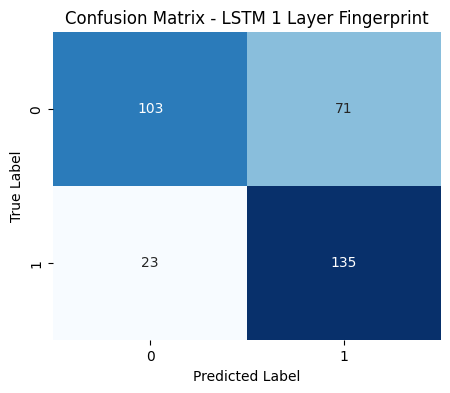

In [ ]:
# Predictions
y_pred1_df1 = (model_1_df1.predict(X1_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 1 Layer Fingerprint", y1_test, y_pred1_df1)

## LSTM 2 Layer

In [ ]:
model_2_df1 = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [ ]:
# Compile model
model_2_df1.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_2_df1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 105, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 105, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,441 (521.25 KB)

 Trainable params: 133,441 (521.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_2_df1.fit(
    X1_train, y1_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5066 - loss: 0.6938 - val_accuracy: 0.5548 - val_loss: 0.6909
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5339 - loss: 0.6918 - val_accuracy: 0.5548 - val_loss: 0.6896
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5351 - loss: 0.6907 - val_accuracy: 0.5548 - val_loss: 0.6906
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5576 - loss: 0.6904 - val_accuracy: 0.5548 - val_loss: 0.6898
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5084 - loss: 0.6939 - val_accuracy: 0.5548 - val_loss: 0.6899
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4929 - loss: 0.6946 - val_accuracy: 0.5548 - val_loss: 0.6890
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4926 - loss: 0.6969 - val_accuracy: 0.5548 - val_loss: 0.6878
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5293 - loss: 0.6918 - val_accuracy: 0.

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
=== LSTM 2 Layer Fingerprint ===
Accuracy: 0.7740963855421686
Precision: 0.7485029940119761
Recall: 0.7911392405063291
F1: 0.7692307692307693
Confusion Matrix:
[[132  42]
 [ 33 125]]



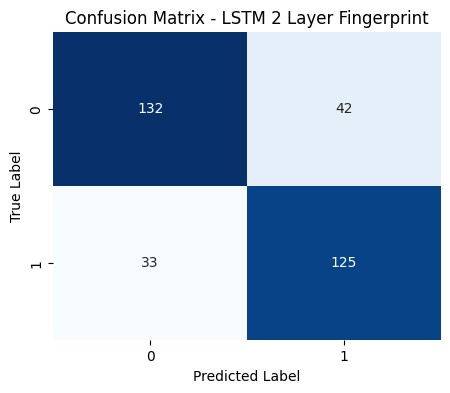

In [ ]:
# Predictions
y_pred2_df1 = (model_2_df1.predict(X1_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 2 Layer Fingerprint", y1_test, y_pred2_df1)

## LSTM 3 Layer

In [ ]:
model_3_df1 = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_3_df1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_3_df1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 105, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 105, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 105, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 105, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,825 (569.63 KB)

 Trainable params: 145,825 (569.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_3_df1.fit(
    X1_train, y1_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4966 - loss: 0.7003 - val_accuracy: 0.5548 - val_loss: 0.6888
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5504 - loss: 0.6928 - val_accuracy: 0.4516 - val_loss: 0.6952
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5029 - loss: 0.6868 - val_accuracy: 0.6839 - val_loss: 0.5945
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6138 - loss: 0.6398 - val_accuracy: 0.6581 - val_loss: 0.6449
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6755 - loss: 0.6199 - val_accuracy: 0.7290 - val_loss: 0.5543
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6774 - loss: 0.5891 - val_accuracy: 0.7226 - val_loss: 0.5170
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6989 - loss: 0.5619 - val_accuracy: 0.7161 - val_loss: 0.5773
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7139 - loss: 0.5744 - val_accuracy: 0.

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
=== LSTM 3 Layer Fingerprint ===
Accuracy: 0.7590361445783133
Precision: 0.7074468085106383
Recall: 0.8417721518987342
F1: 0.7687861271676301
Confusion Matrix:
[[119  55]
 [ 25 133]]



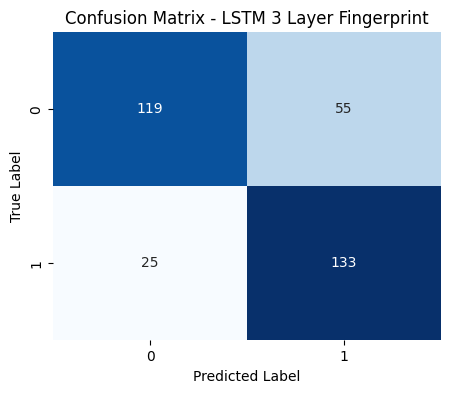

In [ ]:
# Predictions
y_pred3_df1 = (model_3_df1.predict(X1_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 3 Layer Fingerprint", y1_test, y_pred3_df1)

# DATASET 2

In [ ]:
charset = set("".join(list(df2.Smiles))+"!E")
char_to_int = dict((c,i) for i,c in enumerate(charset))
int_to_char = dict((i,c) for i,c in enumerate(charset))
embed = max([len(smile) for smile in df2.Smiles]) + 5
print (str(charset))
print(len(charset), embed)

{'2', '-', 'P', ')', '=', 'o', '5', '4', 'r', '!', 'l', 'B', 'n', '@', 'c', '1', '(', '6', 's', 'F', '+', 'S', 'C', ']', '3', 'I', 'E', '/', '\\', 'N', 'O', 'H', '.', '[', '#'}
35 176


In [ ]:
def vectorize(smiles):
        one_hot =  np.zeros((smiles.shape[0], embed , len(charset)),dtype=np.int8)
        for i,smile in enumerate(smiles):
            #encode the startchar
            one_hot[i,0,char_to_int["!"]] = 1
            #encode the rest of the chars
            for j,c in enumerate(smile):
                one_hot[i,j+1,char_to_int[c]] = 1
            #Encode endchar
            one_hot[i,len(smile)+1:,char_to_int["E"]] = 1
        #Return two, one for input and the other for output
        return one_hot[:,0:-1,:], one_hot[:,1:,:]

In [ ]:
vocab_size=len(charset)
vocab_size

35

In [ ]:
# Definisikan X dan y
X2 = df2['Smiles']
y2 = df2['Label']

In [ ]:
X2.shape

(980,)

In [ ]:
# Split data train-test
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)

In [ ]:
X2_train.shape

(686,)

In [ ]:
X2_train, _ = vectorize(X2_train)
X2_test, _ = vectorize(X2_test)

In [ ]:
X2_train.shape

(686, 175, 35)

In [ ]:
# Input shape
input_shape = (175, 35)

## LSTM 1 Layer

In [ ]:
model_1_df2 = Sequential([
    LSTM(128, return_sequences=False, input_shape=input_shape),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_1_df2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_1_df2.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 128)            │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,097 (328.50 KB)

 Trainable params: 84,097 (328.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_1_df2.fit(
    X2_train, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5352 - loss: 0.6956 - val_accuracy: 0.5290 - val_loss: 0.6931
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5198 - loss: 0.6934 - val_accuracy: 0.5290 - val_loss: 0.6918
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4990 - loss: 0.6923 - val_accuracy: 0.4710 - val_loss: 0.6937
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5272 - loss: 0.6921 - val_accuracy: 0.5290 - val_loss: 0.6915
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5273 - loss: 0.6925 - val_accuracy: 0.5290 - val_loss: 0.6925
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4886 - loss: 0.6953 - val_accuracy: 0.5290 - val_loss: 0.6925
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5134 - loss: 0.6921 - val_accuracy: 0.4638 - val_loss: 0.6932
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4995 - loss: 0.6947 - val_accuracy: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
=== LSTM 1 Layer Fingerprint ===
Accuracy: 0.5170068027210885
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion Matrix:
[[152   0]
 [142   0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


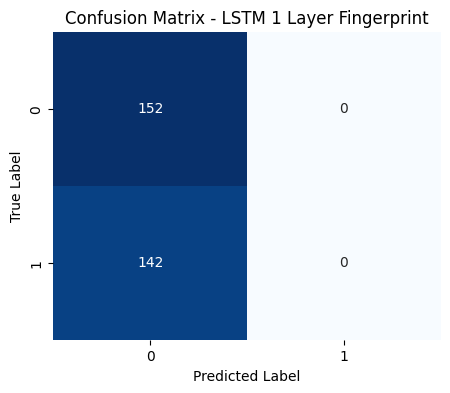

In [ ]:
# Predictions
y_pred1_df2 = (model_1_df2.predict(X2_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 1 Layer Fingerprint", y2_test, y_pred1_df2)

## LSTM 2 Layer

In [ ]:
model_2_df2 = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_2_df2.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_2_df2.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 175, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 175, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,441 (521.25 KB)

 Trainable params: 133,441 (521.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_2_df2.fit(
    X2_train, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5027 - loss: 0.6942 - val_accuracy: 0.5290 - val_loss: 0.6921
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5095 - loss: 0.6938 - val_accuracy: 0.5290 - val_loss: 0.6919
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4601 - loss: 0.6948 - val_accuracy: 0.5290 - val_loss: 0.6922
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5136 - loss: 0.6927 - val_accuracy: 0.5290 - val_loss: 0.6921
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5292 - loss: 0.6930 - val_accuracy: 0.5290 - val_loss: 0.6921
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4727 - loss: 0.6947 - val_accuracy: 0.5290 - val_loss: 0.6923
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5312 - loss: 0.6936 - val_accuracy: 0.5290 - val_loss: 0.6916
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5241 - loss: 0.6912 - val_accuracy: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
=== LSTM 2 Layer Fingerprint ===
Accuracy: 0.5170068027210885
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion Matrix:
[[152   0]
 [142   0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


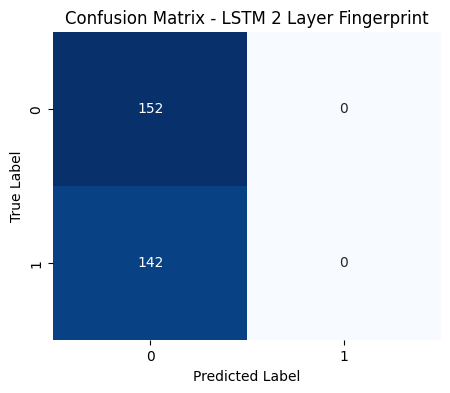

In [ ]:
# Predictions
y_pred2_df2 = (model_2_df2.predict(X2_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 2 Layer Fingerprint", y2_test, y_pred2_df2)

## LSTM 3 Layer

In [ ]:
model_3_df2 = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_3_df2.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_3_df2.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 175, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 175, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 175, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,825 (569.63 KB)

 Trainable params: 145,825 (569.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_3_df2.fit(
    X2_train, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4995 - loss: 0.6940 - val_accuracy: 0.5290 - val_loss: 0.6918
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4895 - loss: 0.6940 - val_accuracy: 0.5290 - val_loss: 0.6926
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5522 - loss: 0.6918 - val_accuracy: 0.5290 - val_loss: 0.6917
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5185 - loss: 0.6929 - val_accuracy: 0.5290 - val_loss: 0.6919
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5061 - loss: 0.6931 - val_accuracy: 0.5290 - val_loss: 0.6920
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5553 - loss: 0.6921 - val_accuracy: 0.5290 - val_loss: 0.6918
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5076 - loss: 0.6938 - val_accuracy: 0.5290 - val_loss: 0.6918
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4977 - loss: 0.6944 - val_accuracy: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
=== LSTM 3 Layer Fingerprint ===
Accuracy: 0.5170068027210885
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion Matrix:
[[152   0]
 [142   0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


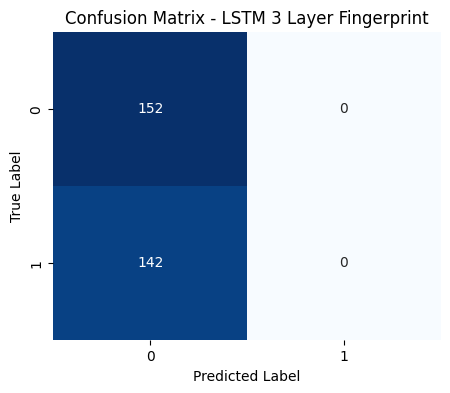

In [ ]:
# Predictions
y_pred3_df2 = (model_3_df2.predict(X2_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 3 Layer Fingerprint", y2_test, y_pred3_df2)

# DATASET FIX (BASELINE MODEL)

In [ ]:
charset = set("".join(list(df3.Smiles))+"!E")
char_to_int = dict((c,i) for i,c in enumerate(charset))
int_to_char = dict((i,c) for i,c in enumerate(charset))
embed = max([len(smile) for smile in df3.Smiles]) + 5
print (str(charset))
print(len(charset), embed)

{'2', '-', 'P', ')', '=', '7', 'o', '5', '4', 'r', '!', 'l', 'B', 'n', '@', 'c', '1', '(', '6', 's', 'F', '+', '8', 'S', 'C', ']', '3', 'I', 'E', '/', '\\', 'H', 'O', 'N', '.', '[', '#'}
37 113


In [ ]:
def vectorize(smiles):
        one_hot =  np.zeros((smiles.shape[0], embed , len(charset)),dtype=np.int8)
        for i,smile in enumerate(smiles):
            #encode the startchar
            one_hot[i,0,char_to_int["!"]] = 1
            #encode the rest of the chars
            for j,c in enumerate(smile):
                one_hot[i,j+1,char_to_int[c]] = 1
            #Encode endchar
            one_hot[i,len(smile)+1:,char_to_int["E"]] = 1
        #Return two, one for input and the other for output
        return one_hot[:,0:-1,:], one_hot[:,1:,:]

In [ ]:
vocab_size=len(charset)
vocab_size

37

In [ ]:
# Definisikan X dan y
X3 = df3['Smiles']
y3 = df3['Label']

In [ ]:
X3.shape

(2666,)

In [ ]:
# Split data train-test
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.3, random_state=42, stratify=y3)

In [ ]:
X3_train.shape

(1866,)

In [ ]:
X3_train, _ = vectorize(X3_train)
X3_test, _ = vectorize(X3_test)

In [ ]:
X3_train.shape

(1866, 112, 37)

In [ ]:
# Input shape
input_shape = (112, 37)

## LSTM 1 Layer

In [ ]:
model_1_df3 = Sequential([
    LSTM(128, return_sequences=False, input_shape=input_shape),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_1_df3.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_1_df3.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 128)            │        84,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,121 (332.50 KB)

 Trainable params: 85,121 (332.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_1_df3.fit(
    X3_train, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4909 - loss: 0.6958 - val_accuracy: 0.5963 - val_loss: 0.6799
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5312 - loss: 0.6941 - val_accuracy: 0.5963 - val_loss: 0.6817
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5472 - loss: 0.6892 - val_accuracy: 0.5963 - val_loss: 0.6812
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5493 - loss: 0.6906 - val_accuracy: 0.5963 - val_loss: 0.6795
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5535 - loss: 0.6891 - val_accuracy: 0.5936 - val_loss: 0.6793
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5620 - loss: 0.6803 - val_accuracy: 0.7032 - val_loss: 0.5831
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6602 - loss: 0.6103 - val_accuracy: 0.6979 - val_loss: 0.5606
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7185 - loss: 0.5616 - val_accuracy: 0.6

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== LSTM 1 Layer Fingerprint ===
Accuracy: 0.74375
Precision: 0.6696629213483146
Recall: 0.8370786516853933
F1: 0.7440699126092385
Confusion Matrix:
[[297 147]
 [ 58 298]]



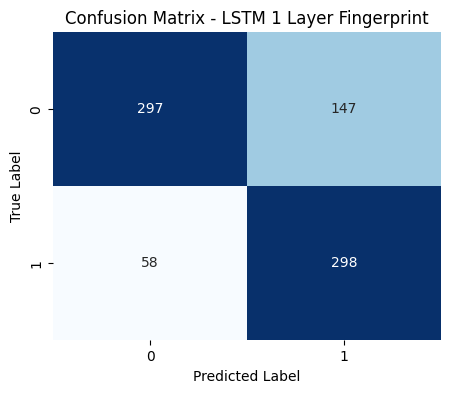

In [ ]:
# Predictions
y_pred1_df3 = (model_1_df3.predict(X3_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 1 Layer Fingerprint", y3_test, y_pred1_df3)

## LSTM 2 Layer

In [ ]:
model_2_df3 = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_2_df3.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_2_df3.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 112, 128)       │        84,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 112, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,465 (525.25 KB)

 Trainable params: 134,465 (525.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_2_df3.fit(
    X3_train, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5439 - loss: 0.6916 - val_accuracy: 0.5963 - val_loss: 0.6827
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5533 - loss: 0.6900 - val_accuracy: 0.5963 - val_loss: 0.6785
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5460 - loss: 0.6888 - val_accuracy: 0.5936 - val_loss: 0.6775
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5802 - loss: 0.6617 - val_accuracy: 0.6898 - val_loss: 0.5654
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6842 - loss: 0.5853 - val_accuracy: 0.6658 - val_loss: 0.5623
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6903 - loss: 0.5712 - val_accuracy: 0.7086 - val_loss: 0.5388
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6954 - loss: 0.5602 - val_accuracy: 0.7059 - val_loss: 0.5357
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7240 - loss: 0.5457 - val_accuracy: 0.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== LSTM 2 Layer Fingerprint ===
Accuracy: 0.755
Precision: 0.6913875598086124
Recall: 0.8117977528089888
F1: 0.7467700258397932
Confusion Matrix:
[[315 129]
 [ 67 289]]



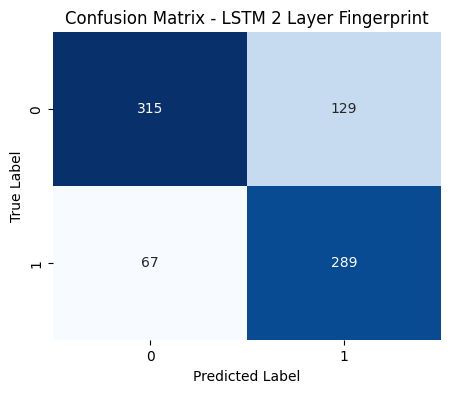

In [ ]:
# Predictions
y_pred2_df3 = (model_2_df3.predict(X3_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 2 Layer Fingerprint", y3_test, y_pred2_df3)

## LSTM 3 Layer

In [ ]:
model_3_df3 = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile model
model_3_df3.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model_3_df3.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 112, 128)       │        84,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 112, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 112, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 112, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,849 (573.63 KB)

 Trainable params: 146,849 (573.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_3_df3.fit(
    X3_train, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5429 - loss: 0.6911 - val_accuracy: 0.5963 - val_loss: 0.6803
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5381 - loss: 0.6907 - val_accuracy: 0.5963 - val_loss: 0.6771
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5400 - loss: 0.6906 - val_accuracy: 0.6016 - val_loss: 0.6360
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6694 - loss: 0.6191 - val_accuracy: 0.6925 - val_loss: 0.5587
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7037 - loss: 0.5906 - val_accuracy: 0.7032 - val_loss: 0.5511
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7055 - loss: 0.5589 - val_accuracy: 0.6471 - val_loss: 0.6055
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7329 - loss: 0.5381 - val_accuracy: 0.7059 - val_loss: 0.5338
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7411 - loss: 0.5266 - val_accuracy: 0.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== LSTM 3 Layer Fingerprint ===
Accuracy: 0.795
Precision: 0.7637362637362637
Recall: 0.7808988764044944
F1: 0.7722222222222223
Confusion Matrix:
[[358  86]
 [ 78 278]]



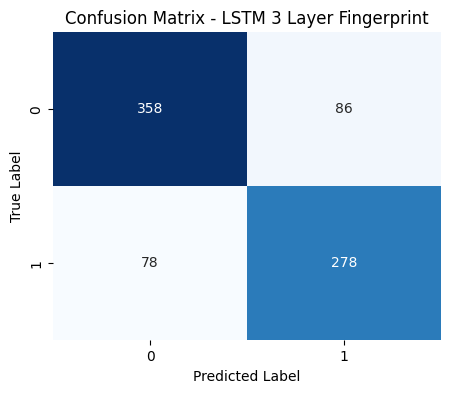

In [ ]:
# Predictions
y_pred3_df3 = (model_3_df3.predict(X3_test) > 0.5).astype(int).flatten()

# Model Evaluate
evaluate_model("LSTM 3 Layer Fingerprint", y3_test, y_pred3_df3)

# COMPARE TIAP DATASET

In [ ]:
df_hasil = pd.DataFrame({
    'Dataset': ['Dataset 1', 'Dataset 1', 'Dataset 1',
                'Dataset 2', 'Dataset 2', 'Dataset 2',
                'Dataset 3', 'Dataset 3', 'Dataset 3'],
    'Layer': ['LSTM-1', 'LSTM-2', 'LSTM-3'] * 3,
    'Accuracy': [0.71, 0.77, 0.75, 0.51, 0.51, 0.51, 0.74, 0.75, 0.79],
    'Precision': [0.65, 0.74, 0.70, 0.0, 0.0, 0.0, 0.66, 0.69, 0.76],
    'Recall': [0.85, 0.79, 0.84, 0.0, 0.0, 0.0, 0.73, 0.81, 0.78],
    'F1-Score': [0.74, 0.76, 0.76, 0.0, 0.0, 0.0, 0.74, 0.74, 0.77]
})

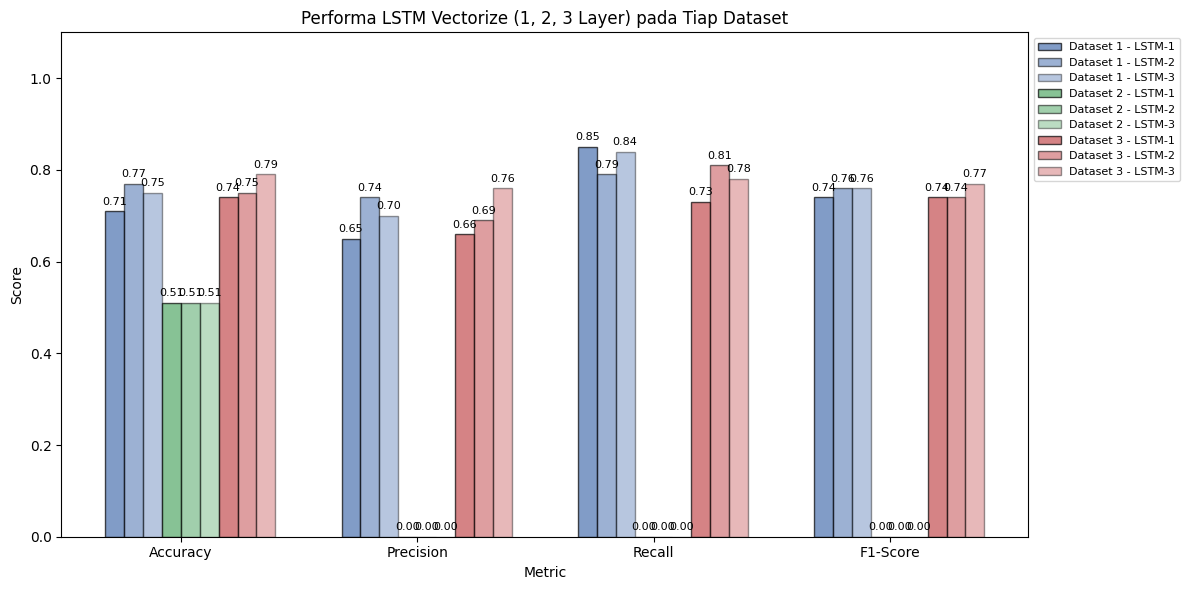

In [ ]:
# --- Plot ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
datasets = df_hasil['Dataset'].unique()
layers = df_hasil['Layer'].unique()

x = np.arange(len(metrics))
width = 0.08  # Lebar bar
fig, ax = plt.subplots(figsize=(12,6))

# Warna per dataset
dataset_colors = ['#4C72B0', '#55A868', '#C44E52']

# Offset posisi bar per dataset-layer
offset = 0
for d_i, dataset in enumerate(datasets):
    df_d = df_hasil[df_hasil['Dataset'] == dataset]
    for l_i, layer in enumerate(layers):
        row = df_d[df_d['Layer'] == layer].iloc[0]
        y = [row[m] for m in metrics]

        bars = ax.bar(
            x + offset,
            y,
            width,
            label=f'{dataset} - {layer}',
            color=dataset_colors[d_i],
            alpha=0.7 - (l_i * 0.15),  # transparansi sedikit beda tiap layer
            edgecolor='black'
        )

        # Tampilkan angka di atas bar
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8
            )

        offset += width  # geser posisi bar

# --- Kustomisasi ---
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.set_title('Performa LSTM Vectorize (1, 2, 3 Layer) pada Tiap Dataset')
ax.set_xticks(x + (len(datasets)*len(layers)*width)/2 - width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()